# HIV Molecular Activity Prediction using Graph Neural Networks

## Project Overview

This project uses **Graph Isomorphism Networks (GIN)** to predict whether molecules can inhibit HIV replication. 

### Why GNNs for Molecules?
- **Molecules are natural graphs**: Atoms are nodes, bonds are edges
- **Spatial relationships matter**: Chemical properties depend on molecular structure
- **Traditional ML fails**: Can't capture topological information effectively

### Dataset: HIV MoleculeNet
- **Source**: MoleculeNet benchmark (available via PyTorch Geometric)
- **Task**: Binary classification (active/inactive against HIV)
- **Size**: ~41,000 molecules with experimentally validated labels
- **Features**: Atom types, bonds, molecular graphs


In [1]:
# Install required packages
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install torch-geometric
!pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install rdkit-pypi matplotlib seaborn scikit-learn pandas numpy tqdm

Looking in indexes: https://download.pytorch.org/whl/cpu
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib
ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi


In [2]:
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GINConv, global_add_pool, global_mean_pool
from torch_geometric.datasets import MoleculeNet
from torch_geometric.utils import degree
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.metrics import roc_curve, precision_recall_curve, classification_report
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
PyTorch version: 2.10.0


## Data Loading

In [3]:
def load_hiv_dataset(root='./data'):
    dataset = MoleculeNet(root=root, name='HIV')
    print(f"   Total molecules: {len(dataset)}")
    print(f"   Number of features per node (atom): {dataset.num_node_features}")
    print(f"   Number of edge features: {dataset.num_edge_features}")
    print(f"   Number of classes: {dataset.num_classes}")
    return dataset
dataset = load_hiv_dataset()

Processing...
Done!


   Total molecules: 41120
   Number of features per node (atom): 9
   Number of edge features: 3
   Number of classes: 2


In [4]:
def explore_dataset(dataset):
    sample_mol = dataset[0]
    print(f"   Number of atoms (nodes): {sample_mol.num_nodes}")
    print(f"   Number of bonds (edges): {sample_mol.num_edges}")
    print(f"   Node feature shape: {sample_mol.x.shape}")
    print(f"   Edge index shape: {sample_mol.edge_index.shape}")
    print(f"   Label shape: {sample_mol.y.shape}")
    print(f"   Label value: {sample_mol.y.item()} (1=Active, 0=Inactive)")
    
    # statistics
    num_nodes = [data.num_nodes for data in dataset]
    num_edges = [data.num_edges for data in dataset]
    labels = [data.y.item() for data in dataset]
    
    print("\nDataset Statistics:")
    print(f"   Average atoms per molecule: {np.mean(num_nodes):.2f} ± {np.std(num_nodes):.2f}")
    print(f"   Average bonds per molecule: {np.mean(num_edges):.2f} ± {np.std(num_edges):.2f}")
    print(f"   Active molecules: {sum(labels)} ({100*sum(labels)/len(labels):.2f}%)")
    print(f"   Inactive molecules: {len(labels)-sum(labels)} ({100*(len(labels)-sum(labels))/len(labels):.2f}%)")
    return num_nodes, num_edges, labels
num_nodes, num_edges, labels = explore_dataset(dataset)

   Number of atoms (nodes): 19
   Number of bonds (edges): 40
   Node feature shape: torch.Size([19, 9])
   Edge index shape: torch.Size([2, 40])
   Label shape: torch.Size([1, 1])
   Label value: 0.0 (1=Active, 0=Inactive)

Dataset Statistics:
   Average atoms per molecule: 25.51 ± 12.11
   Average bonds per molecule: 54.93 ± 26.42
   Active molecules: 1443.0 (3.51%)
   Inactive molecules: 39677.0 (96.49%)


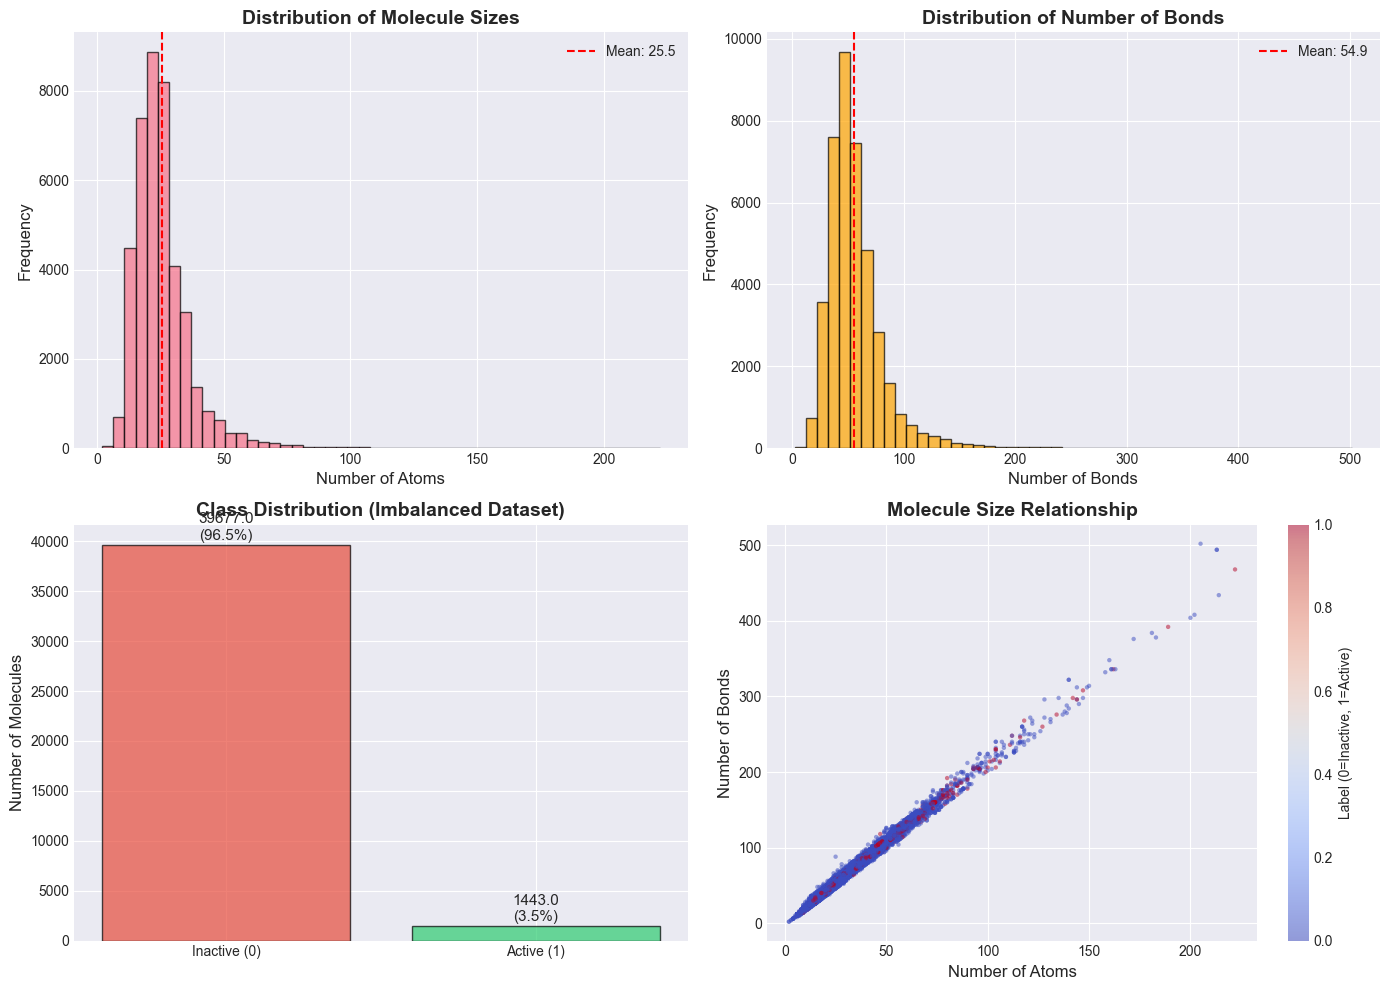


 Visualization saved as 'outputs/dataset_statistics.png'


In [5]:
def visualize_dataset_statistics(num_nodes, num_edges, labels):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0, 0].hist(num_nodes, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Number of Atoms', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].set_title('Distribution of Molecule Sizes', fontsize=14, fontweight='bold')
    axes[0, 0].axvline(np.mean(num_nodes), color='red', linestyle='--', 
                       label=f'Mean: {np.mean(num_nodes):.1f}')
    axes[0, 0].legend()
    axes[0, 1].hist(num_edges, bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 1].set_xlabel('Number of Bonds', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].set_title('Distribution of Number of Bonds', fontsize=14, fontweight='bold')
    axes[0, 1].axvline(np.mean(num_edges), color='red', linestyle='--',
                       label=f'Mean: {np.mean(num_edges):.1f}')
    axes[0, 1].legend()
    class_counts = [len(labels) - sum(labels), sum(labels)]
    axes[1, 0].bar(['Inactive (0)', 'Active (1)'], class_counts, 
                   color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.7)
    axes[1, 0].set_ylabel('Number of Molecules', fontsize=12)
    axes[1, 0].set_title('Class Distribution (Imbalanced Dataset)', fontsize=14, fontweight='bold')
    for i, count in enumerate(class_counts):
        axes[1, 0].text(i, count + 500, f'{count}\n({100*count/len(labels):.1f}%)', 
                        ha='center', fontsize=11)
    scatter = axes[1, 1].scatter(num_nodes, num_edges, c=labels, cmap='coolwarm', 
                                alpha=0.5, s=10, edgecolors='none')
    axes[1, 1].set_xlabel('Number of Atoms', fontsize=12)
    axes[1, 1].set_ylabel('Number of Bonds', fontsize=12)
    axes[1, 1].set_title('Molecule Size Relationship', fontsize=14, fontweight='bold')
    plt.colorbar(scatter, ax=axes[1, 1], label='Label (0=Inactive, 1=Active)')
    plt.tight_layout()
    plt.savefig('outputs/dataset_statistics.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n Visualization saved as 'outputs/dataset_statistics.png'")
visualize_dataset_statistics(num_nodes, num_edges, labels)

##  Train-Validation-Test Split

In [6]:
def create_data_splits(dataset, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1"
    np.random.seed(seed)
    torch.manual_seed(seed)
    num_samples = len(dataset)
    indices = np.random.permutation(num_samples)
    train_end = int(train_ratio * num_samples)
    val_end = train_end + int(val_ratio * num_samples)
    train_indices = indices[:train_end]
    val_indices = indices[train_end:val_end]
    test_indices = indices[val_end:]
    train_dataset = [dataset[i] for i in train_indices]
    val_dataset = [dataset[i] for i in val_indices]
    test_dataset = [dataset[i] for i in test_indices]
    print(f"   Training samples: {len(train_dataset)} ({100*len(train_dataset)/num_samples:.1f}%)")
    print(f"   Validation samples: {len(val_dataset)} ({100*len(val_dataset)/num_samples:.1f}%)")
    print(f"   Test samples: {len(test_dataset)} ({100*len(test_dataset)/num_samples:.1f}%)")
    train_labels = [data.y.item() for data in train_dataset]
    val_labels = [data.y.item() for data in val_dataset]
    test_labels = [data.y.item() for data in test_dataset]
    return train_dataset, val_dataset, test_dataset

train_dataset, val_dataset, test_dataset = create_data_splits(dataset)

   Training samples: 28783 (70.0%)
   Validation samples: 6168 (15.0%)
   Test samples: 6169 (15.0%)


In [7]:
def create_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=64):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"   Batch size: {batch_size}")
    print(f"   Training batches: {len(train_loader)}")
    print(f"   Validation batches: {len(val_loader)}")
    print(f"   Test batches: {len(test_loader)}")
    return train_loader, val_loader, test_loader
train_loader, val_loader, test_loader = create_dataloaders(train_dataset, val_dataset, test_dataset)

   Batch size: 64
   Training batches: 450
   Validation batches: 97
   Test batches: 97


## GIN Model Architecture

### Graph Isomorphism Network (GIN)

GIN updates node embeddings using:

$$h_v^{(k+1)} = \text{MLP}^{(k)} \left( (1 + \epsilon^{(k)}) \cdot h_v^{(k)} + \sum_{u \in \mathcal{N}(v)} h_u^{(k)} \right)$$

Where:
- $h_v^{(k)}$ is the embedding of node $v$ at layer $k$
- $\mathcal{N}(v)$ is the neighborhood of node $v$
- $\epsilon$ is a learnable parameter
- MLP is a multi-layer perceptron

**Key Advantages:**
1. Maximally expressive within the class of message-passing GNNs
2. Provably as powerful as the Weisfeiler-Lehman graph isomorphism test
3. Can distinguish different graph structures effectively

In [8]:
class GINModel(nn.Module):
    def __init__(self, 
                 num_node_features,
                 hidden_dim=128,
                 num_layers=5,
                 dropout=0.3,
                 num_classes=2):
        super(GINModel, self).__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        
        self.convs = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        
        mlp = nn.Sequential(
            nn.Linear(num_node_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.convs.append(GINConv(mlp, train_eps=True))
        self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
        
        for _ in range(num_layers - 1):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.convs.append(GINConv(mlp, train_eps=True))
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
        self.pool = global_add_pool
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.BatchNorm1d(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, num_classes)
        )
    
    def forward(self, x, edge_index, batch):
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.pool(x, batch)
        out = self.classifier(x)
        
        return out
model = GINModel(
    num_node_features=dataset.num_node_features,
    hidden_dim=128,
    num_layers=5,
    dropout=0.3,
    num_classes=dataset.num_classes
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n Model Architecture:")
print(model)
print(f"\nTotal trainable parameters: {num_params:,}")


 Model Architecture:
GINModel(
  (convs): ModuleList(
    (0): GINConv(nn=Sequential(
      (0): Linear(in_features=9, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
    ))
    (1-4): 4 x GINConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
    ))
  )
  (batch_norms): ModuleList(
    (0-4): 5 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_fe

## Training Configurations

In [9]:

EPOCHS = 100
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5  
PATIENCE = 15  
train_labels = [data.y.item() for data in train_dataset]
class_counts = [len(train_labels) - sum(train_labels), sum(train_labels)]
class_weights = torch.tensor([1.0 / count for count in class_counts])
class_weights = class_weights / class_weights.sum() 
class_weights = class_weights.to(device)

print(f"\nClass weights (to handle imbalance): {class_weights.cpu().numpy()}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), 
                            lr=LEARNING_RATE, 
                            weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)


Class weights (to handle imbalance): [0.03526387 0.9647361 ]


##  Training Functions

In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(loader, desc='Training', leave=False):
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        target = batch.y.squeeze().long() if batch.y.dim() > 1 else batch.y.long()
        loss = criterion(out, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        pred = out.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)
        total_loss += loss.item() * target.size(0)
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            target = batch.y.squeeze().long() if batch.y.dim() > 1 else batch.y.long()
            loss = criterion(out, target)
            probs = F.softmax(out, dim=1)
            pred = out.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy()) 
            correct += (pred == target).sum().item()
            total += target.size(0)
            total_loss += loss.item() * target.size(0)
    avg_loss = total_loss / total
    accuracy = correct / total
    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
    except:
        roc_auc = 0.0
    return avg_loss, accuracy, roc_auc, all_preds, all_labels, all_probs

## Training Loop

In [11]:
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_roc_auc': []
}
best_val_loss = float('inf')
best_val_roc_auc = 0.0
patience_counter = 0
best_model_state = None
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_roc_auc, _, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_roc_auc'].append(val_roc_auc)
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val ROC-AUC: {val_roc_auc:.4f}")
    if val_roc_auc > best_val_roc_auc:
        best_val_roc_auc = val_roc_auc
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"   New best model! ROC-AUC: {val_roc_auc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            print(f"   Best validation ROC-AUC: {best_val_roc_auc:.4f}")
            break
model.load_state_dict(best_model_state)
print(f"\nBest model loaded (Val ROC-AUC: {best_val_roc_auc:.4f})")

Epoch 001/100 | Train Loss: 0.6620 | Train Acc: 0.7896 | Val Loss: 0.5926 | Val Acc: 0.8778 | Val ROC-AUC: 0.7273
   New best model! ROC-AUC: 0.7273


Epoch 002/100 | Train Loss: 0.6251 | Train Acc: 0.8483 | Val Loss: 0.6092 | Val Acc: 0.6753 | Val ROC-AUC: 0.7416
   New best model! ROC-AUC: 0.7416


Epoch 003/100 | Train Loss: 0.6076 | Train Acc: 0.8462 | Val Loss: 0.5742 | Val Acc: 0.8867 | Val ROC-AUC: 0.7303


Epoch 004/100 | Train Loss: 0.5957 | Train Acc: 0.8546 | Val Loss: 0.5683 | Val Acc: 0.8444 | Val ROC-AUC: 0.7556
   New best model! ROC-AUC: 0.7556


Epoch 005/100 | Train Loss: 0.5949 | Train Acc: 0.8478 | Val Loss: 0.5792 | Val Acc: 0.8178 | Val ROC-AUC: 0.7447


...

Epoch 049/100 | Train Loss: 0.4795 | Train Acc: 0.9247 | Val Loss: 0.5576 | Val Acc: 0.9290 | Val ROC-AUC: 0.7565


Epoch 050/100 | Train Loss: 0.4698 | Train Acc: 0.9263 | Val Loss: 0.5664 | Val Acc: 0.9009 | Val ROC-AUC: 0.7597


Epoch 051/100 | Train Loss: 0.4771 | Train Acc: 0.9252 | Val Loss: 0.5840 | Val Acc: 0.9347 | Val ROC-AUC: 0.7550


Epoch 052/100 | Train Loss: 0.4670 | Train Acc: 0.9275 | Val Loss: 0.5762 | Val Acc: 0.9285 | Val ROC-AUC: 0.7616


Epoch 053/100 | Train Loss: 0.4750 | Train Acc: 0.9299 | Val Loss: 0.5888 | Val Acc: 0.9288 | Val ROC-AUC: 0.7527

Early stopping triggered after 53 epochs
   Best validation ROC-AUC: 0.7786

Best model loaded (Val ROC-AUC: 0.7786)


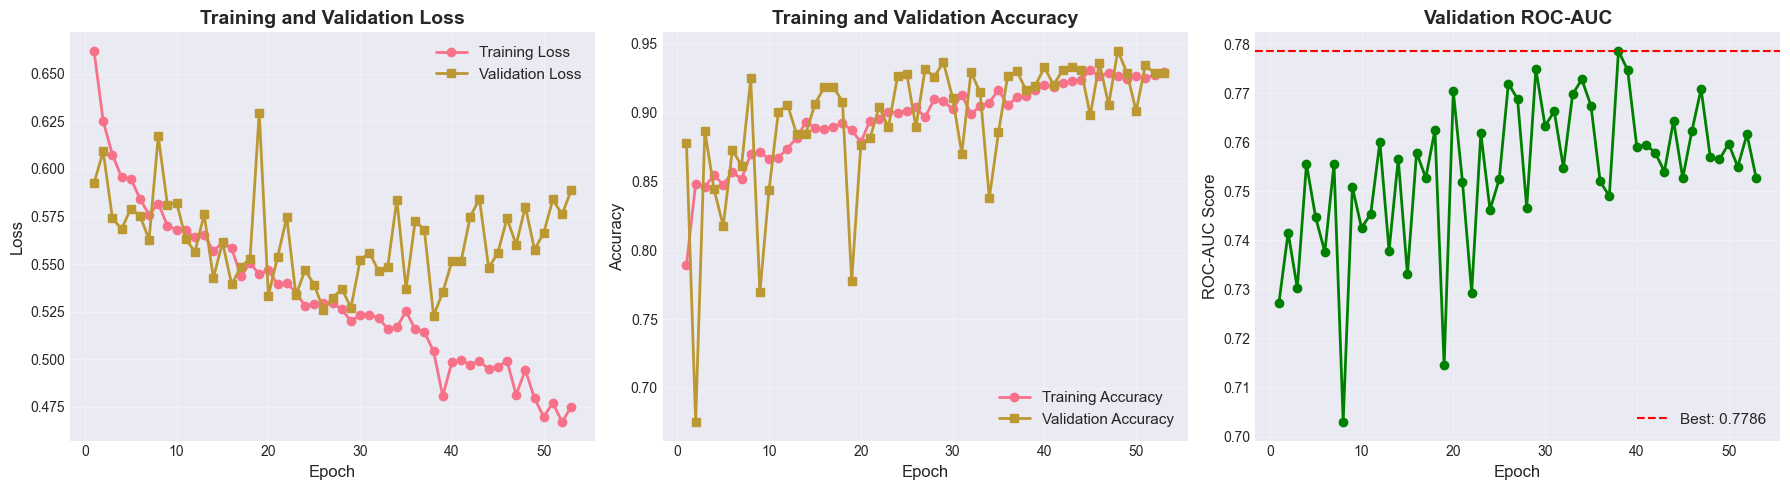


Training history visualization saved as 'outputs/training_history.png'


In [12]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs, history['train_loss'], 'o-', label='Training Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 's-', label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['train_acc'], 'o-', label='Training Accuracy', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 's-', label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(epochs, history['val_roc_auc'], 'o-', color='green', linewidth=2)
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('ROC-AUC Score', fontsize=12)
    axes[2].set_title('Validation ROC-AUC', fontsize=14, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=best_val_roc_auc, color='red', linestyle='--', 
                    label=f'Best: {best_val_roc_auc:.4f}')
    axes[2].legend(fontsize=11)
    plt.tight_layout()
    plt.savefig('outputs/training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nTraining history visualization saved as 'outputs/training_history.png'")
plot_training_history(history)

## Model Evaluation on Test Set

In [13]:
test_loss, test_acc, test_roc_auc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, device
)
print("TEST SET RESULTS")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({100*test_acc:.2f}%)")
print(f"Test ROC-AUC: {test_roc_auc:.4f}")
avg_precision = average_precision_score(test_labels, test_probs)
print(f"Test Average Precision: {avg_precision:.4f}")
print("\nDetailed Classification Report:\n")
print(classification_report(test_labels, test_preds, 
                          target_names=['Inactive (0)', 'Active (1)'],
                          digits=4))

TEST SET RESULTS
Test Loss: 0.5817
Test Accuracy: 0.9261 (92.61%)
Test ROC-AUC: 0.7870
Test Average Precision: 0.3480

Detailed Classification Report:

              precision    recall  f1-score   support

Inactive (0)     0.9819    0.9406    0.9608      5947
  Active (1)     0.2521    0.5360    0.3429       222

    accuracy                         0.9261      6169
   macro avg     0.6170    0.7383    0.6519      6169
weighted avg     0.9557    0.9261    0.9386      6169



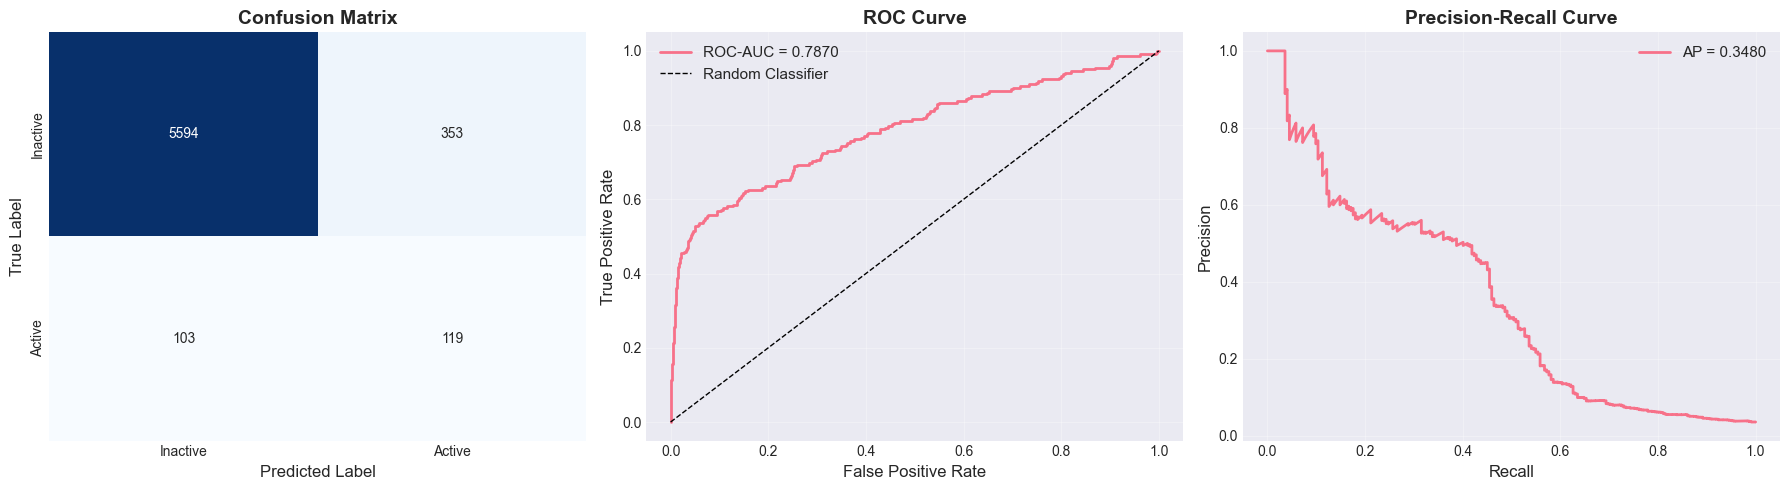


Evaluation results saved as 'outputs/evaluation_results.png'


In [14]:
def plot_evaluation_results(test_labels, test_preds, test_probs):
    fig = plt.figure(figsize=(18, 5))
    ax1 = plt.subplot(1, 3, 1)
    cm = confusion_matrix(test_labels, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1)
    ax1.set_xlabel('Predicted Label', fontsize=12)
    ax1.set_ylabel('True Label', fontsize=12)
    ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    ax1.set_xticklabels(['Inactive', 'Active'])
    ax1.set_yticklabels(['Inactive', 'Active'])
    ax2 = plt.subplot(1, 3, 2)
    fpr, tpr, _ = roc_curve(test_labels, test_probs)
    ax2.plot(fpr, tpr, linewidth=2, label=f'ROC-AUC = {test_roc_auc:.4f}')
    ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax3 = plt.subplot(1, 3, 3)
    precision, recall, _ = precision_recall_curve(test_labels, test_probs)
    avg_prec = average_precision_score(test_labels, test_probs)
    ax3.plot(recall, precision, linewidth=2, label=f'AP = {avg_prec:.4f}')
    ax3.set_xlabel('Recall', fontsize=12)
    ax3.set_ylabel('Precision', fontsize=12)
    ax3.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=11)
    ax3.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/evaluation_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nEvaluation results saved as 'outputs/evaluation_results.png'")
plot_evaluation_results(test_labels, test_preds, test_probs)

## Prediction Analysis

In [15]:
def analyze_predictions(test_dataset, test_preds, test_probs, test_labels, num_examples=10):
    correct_indices = [i for i, (pred, label) in enumerate(zip(test_preds, test_labels)) 
                      if pred == label]
    incorrect_indices = [i for i, (pred, label) in enumerate(zip(test_preds, test_labels)) 
                        if pred != label]
    print(f"Correct predictions: {len(correct_indices)} ({100*len(correct_indices)/len(test_labels):.2f}%)")
    print(f"Incorrect predictions: {len(incorrect_indices)} ({100*len(incorrect_indices)/len(test_labels):.2f}%)")
    print("\nExamples of Confident Correct Predictions:\n")
    confident_correct = [(i, test_probs[i]) for i in correct_indices]
    confident_correct.sort(key=lambda x: abs(x[1] - 0.5), reverse=True) 
    for idx, (i, prob) in enumerate(confident_correct[:num_examples]):
        mol = test_dataset[i]
        true_label = test_labels[i]
        pred_label = test_preds[i]
        confidence = prob if pred_label == 1 else (1 - prob)
        print(f"{idx+1}. Molecule {i}:")
        print(f"   Atoms: {mol.num_nodes}, Bonds: {mol.num_edges}")
        print(f"   True: {'Active' if true_label == 1 else 'Inactive'}")
        print(f"   Predicted: {'Active' if pred_label == 1 else 'Inactive'} (Confidence: {confidence:.4f})")
        print()
    if len(incorrect_indices) > 0:
        print("\nExamples of Misclassified Molecules:\n")
        for idx, i in enumerate(incorrect_indices[:num_examples]):
            mol = test_dataset[i]
            true_label = test_labels[i]
            pred_label = test_preds[i]
            prob = test_probs[i]
            confidence = prob if pred_label == 1 else (1 - prob)
            print(f"{idx+1}. Molecule {i}:")
            print(f"   Atoms: {mol.num_nodes}, Bonds: {mol.num_edges}")
            print(f"   True: {'Active' if true_label == 1 else 'Inactive'}")
            print(f"   Predicted: {'Active' if pred_label == 1 else 'Inactive'} (Confidence: {confidence:.4f})")
            print()
analyze_predictions(test_dataset, test_preds, test_probs, test_labels)

Correct predictions: 5713 (92.61%)
Incorrect predictions: 456 (7.39%)

Examples of Confident Correct Predictions:

1. Molecule 5187:
   Atoms: 77, Bonds: 164
   True: Active
   Predicted: Active (Confidence: 1.0000)

2. Molecule 1325:
   Atoms: 64, Bonds: 150
   True: Inactive
   Predicted: Inactive (Confidence: 0.9997)

3. Molecule 2356:
   Atoms: 49, Bonds: 102
   True: Active
   Predicted: Active (Confidence: 0.9994)

4. Molecule 3703:
   Atoms: 72, Bonds: 158
   True: Active
   Predicted: Active (Confidence: 0.9993)

5. Molecule 5530:
   Atoms: 95, Bonds: 206
   True: Active
   Predicted: Active (Confidence: 0.9993)

6. Molecule 1383:
   Atoms: 77, Bonds: 170
   True: Inactive
   Predicted: Inactive (Confidence: 0.9991)

7. Molecule 2361:
   Atoms: 63, Bonds: 138
   True: Inactive
   Predicted: Inactive (Confidence: 0.9991)

8. Molecule 4486:
   Atoms: 76, Bonds: 164
   True: Active
   Predicted: Active (Confidence: 0.9988)

9. Molecule 3979:
   Atoms: 75, Bonds: 162
   True: Activ

## Save Model

In [16]:
model_save_path = 'outputs/best_gin_model.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_roc_auc': best_val_roc_auc,
    'test_roc_auc': test_roc_auc,
    'test_accuracy': test_acc,
    'history': history,
    'model_config': {
        'num_node_features': dataset.num_node_features,
        'hidden_dim': 128,
        'num_layers': 5,
        'dropout': 0.3,
        'num_classes': dataset.num_classes
    }
}, model_save_path)

print(f"\nModel saved to: {model_save_path}")
print(f"\n   Best validation ROC-AUC: {best_val_roc_auc:.4f}")
print(f"   Test ROC-AUC: {test_roc_auc:.4f}")
print(f"   Test Accuracy: {test_acc:.4f}")


Model saved to: outputs/best_gin_model.pth

   Best validation ROC-AUC: 0.7786
   Test ROC-AUC: 0.7870
   Test Accuracy: 0.9261


## Making Predictions on New Molecules

In [20]:
def predict_molecule(model, molecule_data, device):
    model.eval()
    
    with torch.no_grad():
        molecule_data = molecule_data.to(device)
        batch = torch.zeros(molecule_data.num_nodes, dtype=torch.long, device=device)
        
        out = model(molecule_data.x, molecule_data.edge_index, batch)
        probs = F.softmax(out, dim=1)
        prediction = out.argmax(dim=1).item()
        probability = probs[0, 1].item()
    return prediction, probability

example_molecule = test_dataset[0]
prediction, confidence = predict_molecule(model, example_molecule, device)

print("\nExample Prediction:\n")
print(f"Molecule characteristics:")
print(f"  Number of atoms: {example_molecule.num_nodes}")
print(f"  Number of bonds: {example_molecule.num_edges}")
print(f"\nPrediction: {'Active ' if prediction == 1 else 'Inactive '}")
print(f"Confidence: {confidence:.4f}")
print(f"True label: {'Active' if example_molecule.y.item() == 1 else 'Inactive'}")


Example Prediction:

Molecule characteristics:
  Number of atoms: 20
  Number of bonds: 44

Prediction: Inactive 
Confidence: 0.2700
True label: Inactive
